In [260]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_tenure_sorting import ModelClass
# from Old_models.main_agent_based import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

from graphs import *

import copy


np.set_printoptions(threshold=np.inf)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Increase chance of being reassigned

In [261]:
# Baseline
model = ModelClass()
model.solve(do_print=True)

par = model.par

params_to_latex(par)


Iteration:  1 eps =  inf
Iteration:  2 eps =  1.0
Iteration:  3 eps =  2.0
Iteration:  4 eps =  3.0
Iteration:  5 eps =  4.0
Iteration:  6 eps =  5.0
Iteration:  7 eps =  6.0
Iteration:  8 eps =  7.0
Iteration:  9 eps =  8.0
Iteration:  10 eps =  9.0
Iteration:  11 eps =  10.0
Iteration:  12 eps =  11.0
Iteration:  13 eps =  12.0
Iteration:  14 eps =  13.0
Iteration:  15 eps =  14.0
Iteration:  16 eps =  15.0
Iteration:  17 eps =  16.0
Iteration:  18 eps =  17.0
Iteration:  19 eps =  18.0
Iteration:  20 eps =  19.0
Iteration:  21 eps =  20.0
Iteration:  22 eps =  21.0
Iteration:  23 eps =  22.0
Iteration:  24 eps =  23.0
Iteration:  25 eps =  24.0
Iteration:  26 eps =  25.0
Iteration:  27 eps =  26.0
Iteration:  28 eps =  27.0
Iteration:  29 eps =  28.0
Iteration:  30 eps =  29.0
Iteration:  31 eps =  30.0
Iteration:  32 eps =  31.0
Iteration:  33 eps =  32.0
Iteration:  34 eps =  33.0
Iteration:  35 eps =  34.0
Iteration:  36 eps =  35.0
Iteration:  37 eps =  36.0
Iteration:  38 eps =

In [262]:
first_period = 10
second_period = 20

rho_baseline = model.par.rho.copy()

# Periods 0–9: baseline
model.par.rho = rho_baseline.copy()
model.par.T_max = first_period
model.generate_transition(t_end=first_period - 1, do_print=False)
sol1 = copy.deepcopy(model.sol)

# Initial steady-state period plus 20 shocked periods
rho_shock = rho_baseline.copy()
rho_shock = np.concatenate([rho_baseline[:2], rho_baseline[:-2]])
model.par.rho = rho_shock
model.par.T_max = second_period + 1
model.generate_transition(t_end=second_period, do_print=False)
sol2 = copy.deepcopy(model.sol)

# Drop sol2 period 0 because it duplicates the pre-shock steady state
for name, x1 in vars(sol1).items():
    x2 = getattr(sol2, name)

    if (
        isinstance(x1, np.ndarray)
        and isinstance(x2, np.ndarray)
        and x1.ndim >= 1
        and x2.ndim == x1.ndim
        and x1.shape[0] == first_period
        and x2.shape[0] == second_period + 1
        and x1.shape[1:] == x2.shape[1:]
    ):
        setattr(
            model.sol,
            name,
            np.concatenate((x1, x2[1:]), axis=0),
        )

model.par.T_max = first_period + second_period

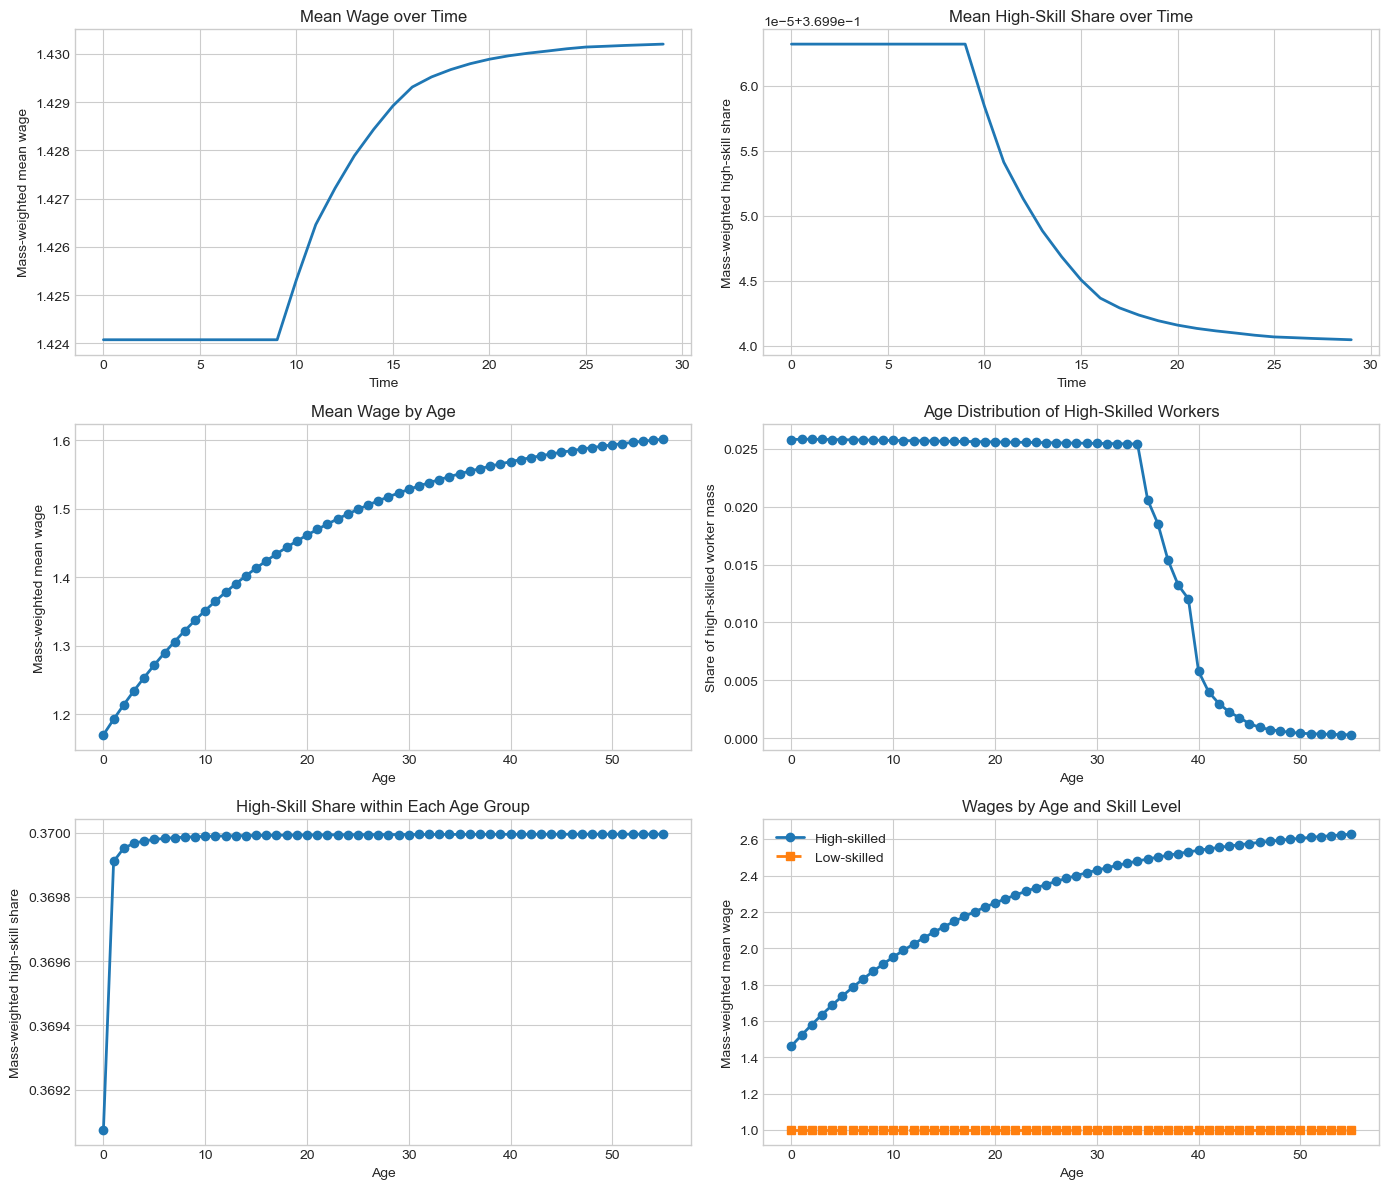

In [263]:
plot_model(model, time = first_period)

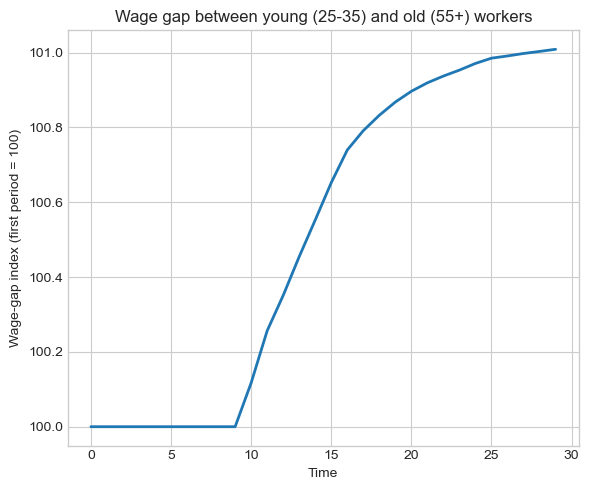

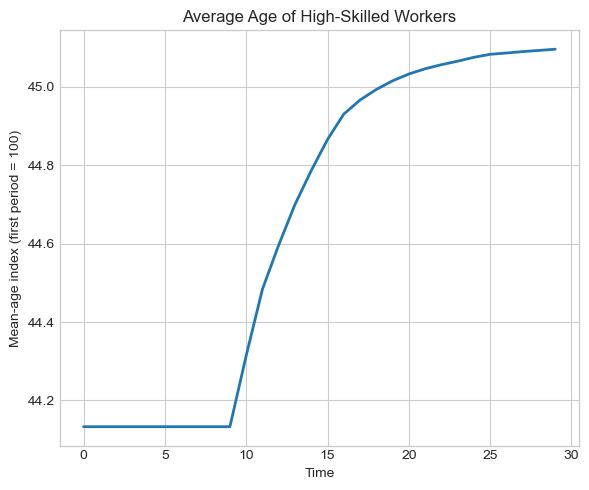

In [264]:
plot_wage_gap(model, young_max = 10, old_min = 30, x_size=6, y_size=5)
plot_mean_age_high_skill(model, x_size=6, y_size=5)

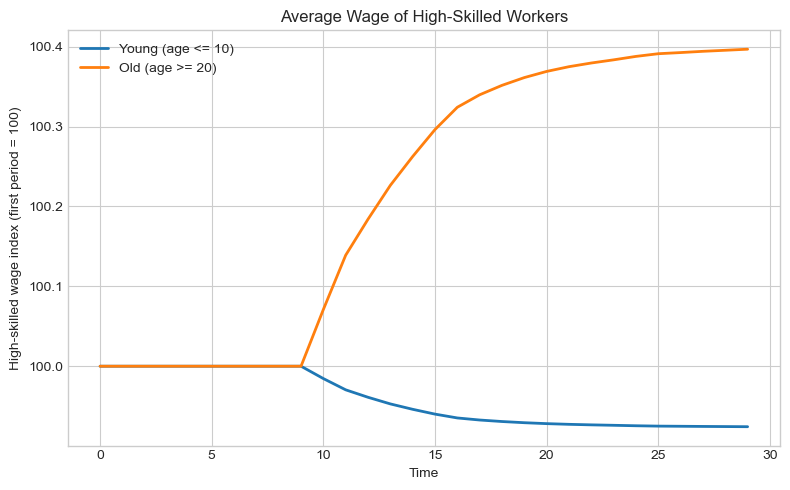

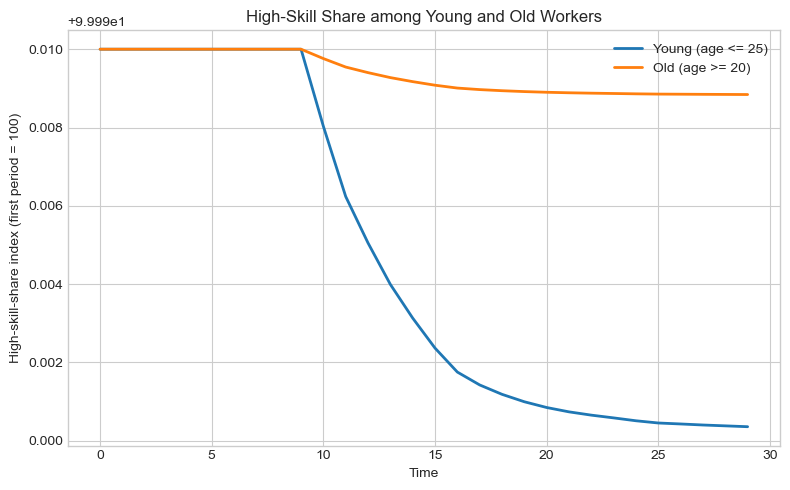

In [265]:
plot_high_skill_wages_young_old(model, young_max=10, old_min=20)
plot_high_skill_shares_young_old(model, young_max=25, old_min=20)

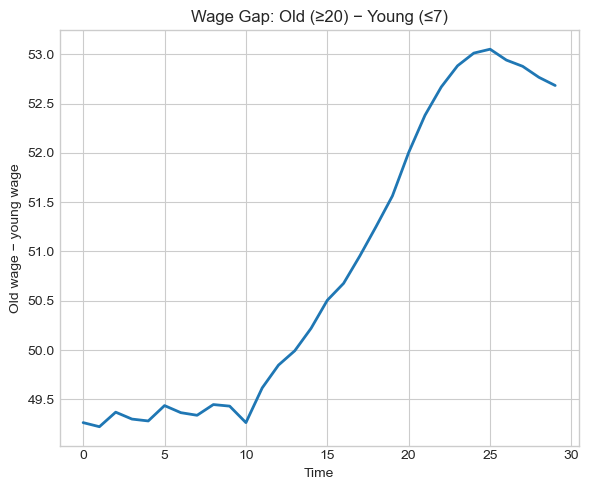

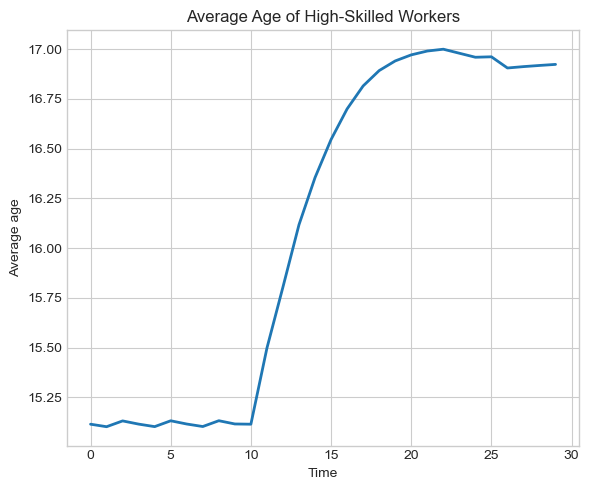